# Tutorial 2: Object-Oriented Programming, Matplotlib & The Geometric Product

In this tutorial, we'll build a complete Vector class from scratch using Object-Oriented Programming (OOP), learn how to visualize vectors using Matplotlib, and implement the geometric product from Geometric Algebra.

## 0. Setup: Importing Libraries

We'll need NumPy for efficient numerical operations and Matplotlib for visualization.

In [100]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 1: Object-Oriented Programming (OOP)

### 1.1 Why Use Classes?

In Class 1, we used NumPy arrays to represent vectors: `np.array([2, 1])`. While NumPy is great for basic operations, **classes** allow us to:

- Bundle data (vector components) with behavior (operations)
- Write readable code: `v1.wedge(v2)` instead of `v1[0]*v2[1] - v1[1]*v2[0]`
- Define custom operations specific to Geometric Algebra
- Make our code self-documenting

A **class** is a blueprint for creating objects. Let's start with a simple example:

In [101]:
# Simple example: Point class
class Point:
    """A simple 2D point."""
    
    def __init__(self, x, y):
        """Constructor: Initialize the point with x and y coordinates."""
        self.x = x  # Property (data)
        self.y = y  # Property (data)
    
    def distance_from_origin(self):
        """Method: Calculate distance from origin."""
        return (self.x**2 + self.y**2)**0.5

# Create instances (objects)
p1 = Point(3, 4)
p2 = Point(0, 5)

print(f"Point 1: ({p1.x}, {p1.y})")
print(f"Distance from origin: {p1.distance_from_origin()}")
print(f"Point 2: ({p2.x}, {p2.y})")
print(f"Distance from origin: {p2.distance_from_origin()}")

Point 1: (3, 4)
Distance from origin: 5.0
Point 2: (0, 5)
Distance from origin: 5.0


### 1.2 Properties vs Methods

- **Properties** (attributes): Data stored in the object (`self.x`, `self.y`)
  - Access without parentheses: `p1.x`
- **Methods**: Functions that act on the object
  - Call with parentheses: `p1.distance_from_origin()`

In [102]:
# Accessing properties
print(f"p1.x = {p1.x}")  # Property access (no parentheses)

# Modifying properties
p1.x = 10
print(f"After modification: p1.x = {p1.x}")
print(f"New distance: {p1.distance_from_origin()}")

p1.x = 3
After modification: p1.x = 10
New distance: 10.770329614269007


### 1.3 Magic Methods (Operator Overloading)

**Magic methods** (also called "dunder methods" for double underscore) let us define how operators work with our objects. Common ones:

- `__init__`: Constructor
- `__str__`: How `print()` shows the object
- `__repr__`: Developer representation
- `__add__`: The `+` operator
- `__mul__`: The `*` operator

Let's see an example:

In [103]:
# Shopping cart example
class ShoppingCart:
    """A shopping cart that can use the + operator."""
    
    def __init__(self):
        self.items = []
    
    def __add__(self, item):
        """Define the '+' operator."""
        self.items.append(item)
        return self
    
    def __str__(self):
        """Define how print() shows this object."""
        return f"Cart with {len(self.items)} items"
    
    def __len__(self):
        """Define the len() function."""
        return len(self.items)

# Usage
cart = ShoppingCart()
cart = cart + "apple"    # Using the + operator!
cart = cart + "banana"

print(cart)              # Calls __str__
print(f"Length: {len(cart)}")  # Calls __len__

Cart with 2 items
Length: 2


### 1.4 Building Our Vector Class

Now let's build a `Vector` class for Geometric Algebra! We'll add features step by step.

#### Step 1: Constructor and String Representation

In [104]:
class Vector:
    """A 2D vector for Geometric Algebra."""
    
    def __init__(self, x, y):
        """Initialize vector with x and y components."""
        self.x = x
        self.y = y
        # Store as NumPy array internally for efficient math
        self._array = np.array([x, y])
    
    def __str__(self):
        """User-friendly string representation."""
        return f"Vector({self.x}, {self.y})"
    
    def __repr__(self):
        """Developer representation (same as __str__ here)."""
        return f"Vector({self.x}, {self.y})"

# Test it
v1 = Vector(2, 3)
v2 = Vector(5, 1)

print(v1)  # Calls __str__
print(f"x component: {v1.x}")
print(f"Internal array: {v1._array}")

print(repr(v1)) # Calls __repr__

Vector(2, 3)
x component: 2
Internal array: [2 3]
Vector(2, 3)


#### Step 2: Addition Operator

In [105]:
# We'll rebuild the class with more features
class Vector:
    """A 2D vector for Geometric Algebra."""
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self._array = np.array([x, y])
    
    def __str__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __repr__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __add__(self, other):
        """Add two vectors using the + operator."""
        new_array = self._array + other._array
        return Vector(new_array[0], new_array[1])

# Test addition
v1 = Vector(2, 1)
v2 = Vector(1, 2)
v3 = v1 + v2  # Using the + operator!

print(f"{v1} + {v2} = {v3}")

Vector(2, 1) + Vector(1, 2) = Vector(3, 3)


#### Step 3: More Operators and Methods

In [106]:
# Complete basic Vector class
class Vector:
    """A 2D vector for Geometric Algebra."""
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self._array = np.array([x, y])
    
    def __str__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __repr__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __add__(self, other):
        """Add two vectors."""
        new_array = self._array + other._array
        return Vector(new_array[0], new_array[1])
    
    def __sub__(self, other):
        """Subtract two vectors."""
        new_array = self._array - other._array
        return Vector(new_array[0], new_array[1])
    
    def __mul__(self, scalar):
        """Multiply vector by a scalar."""
        return Vector(self.x * scalar, self.y * scalar)
    
    def magnitude(self):
        """Calculate the length/magnitude of the vector."""
        return np.linalg.norm(self._array)

# Test all operations
v1 = Vector(3, 4)
v2 = Vector(1, 1)

print(f"v1 = {v1}")
print(f"v2 = {v2}")
print(f"v1 + v2 = {v1 + v2}")
print(f"v1 - v2 = {v1 - v2}")
print(f"v1 * 2 = {v1 * 2}")
print(f"|v1| = {v1.magnitude()}")

v1 = Vector(3, 4)
v2 = Vector(1, 1)
v1 + v2 = Vector(4, 5)
v1 - v2 = Vector(2, 3)
v1 * 2 = Vector(6, 8)
|v1| = 5.0


## Part 2: Visualization with Matplotlib

### 2.1 Matplotlib Hierarchy

Matplotlib has a hierarchical structure:

1. **Figure** (`fig`): The entire canvas/window
2. **Axes** (`ax`): The plot area (where you draw)
3. **Axis**: x-axis and y-axis objects
4. **Artists**: Individual elements (lines, points, shapes)

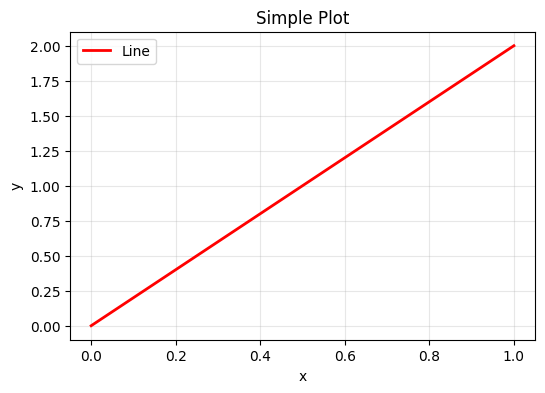

In [107]:
# Simple example
fig, ax = plt.subplots(figsize=(6, 4))

# Draw a line
ax.plot([0, 1], [0, 2], color='red', linewidth=2, label='Line')

# Add labels and grid
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Simple Plot')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

### 2.2 Different Chart Types

Matplotlib can create many types of visualizations. Here are some common ones:

#### Line Plot
Let's plot a simple line plot using the `plot` function. We will plot the function $y = x^2$ for $x$ in the range $[-10, 10]$.

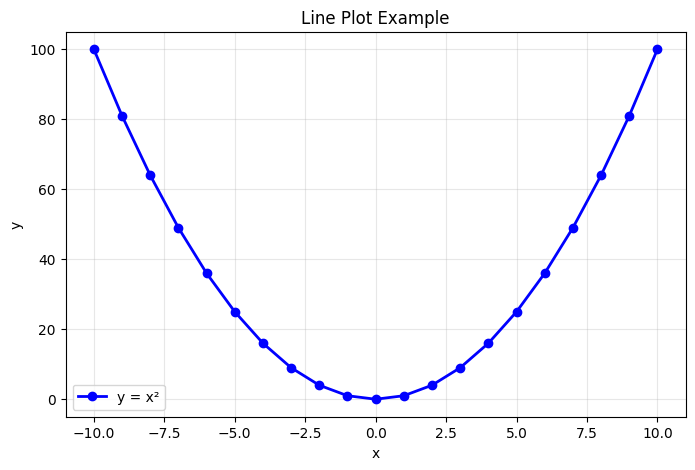

In [108]:
# Line plot
fig, ax = plt.subplots(figsize=(8, 5))

x = list(range(-10, 11))
y = [i**2 for i in x]

ax.plot(x, y, color='blue', linewidth=2, marker='o', label='y = x²')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Line Plot Example')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In case we want to plot multiple lines on the same plot, we can call the `plot` function multiple times before calling `show`.

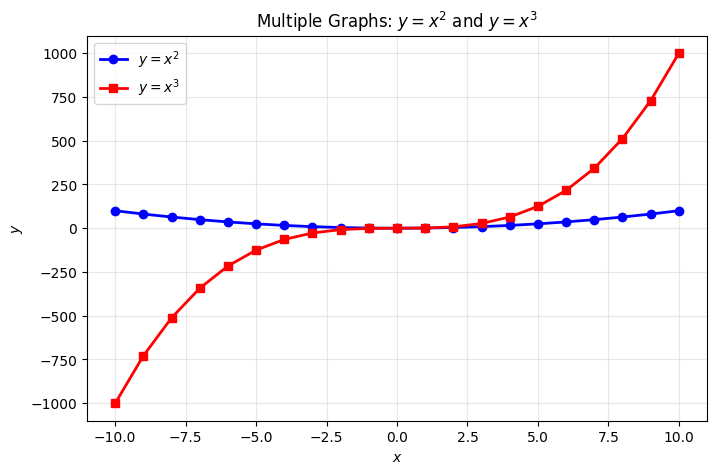

In [109]:
y2 = [i**3 for i in x]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

# Plot both datasets on the same 'ax'
ax.plot(x, y, color='blue', linewidth=2, marker='o', label='$y = x^2$')
ax.plot(x, y2, color='red', linewidth=2, marker='s', label='$y = x^3$')

# Customization
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Multiple Graphs: $y = x^2$ and $y = x^3$')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

#### Scatter Plot
Show individual data points

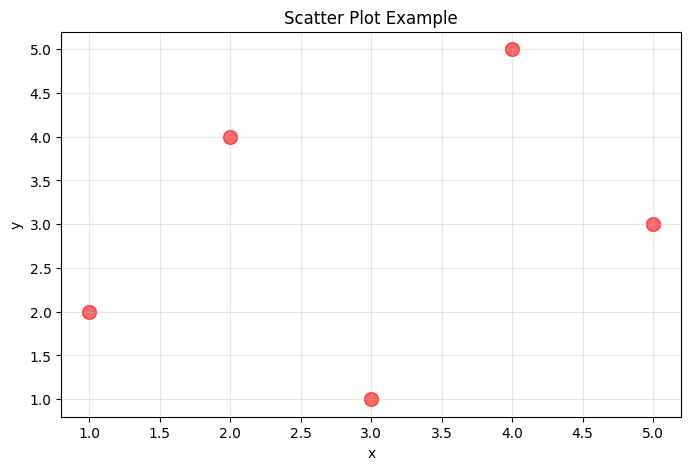

In [110]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8, 5))

x = [1, 2, 3, 4, 5]
y = [2, 4, 1, 5, 3]

ax.scatter(x, y, color='red', s=100, alpha=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Scatter Plot Example')
ax.grid(True, alpha=0.3)

plt.show()

#### Bar Chart
Compare categories with bars

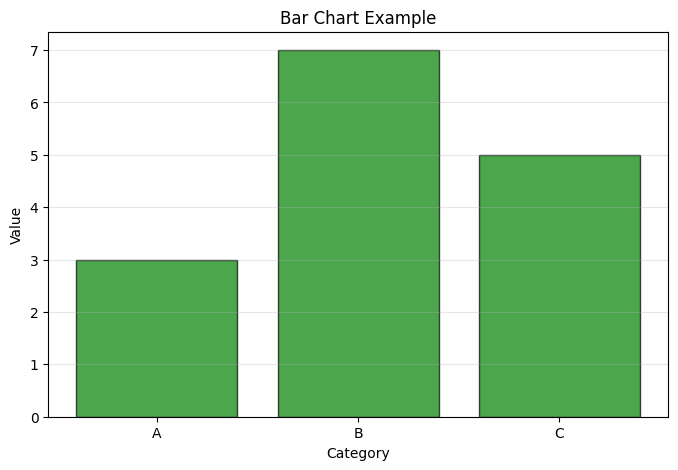

In [111]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['A', 'B', 'C']
values = [3, 7, 5]

ax.bar(categories, values, color='green', edgecolor='black', alpha=0.7)

ax.set_xlabel('Category')
ax.set_ylabel('Value')
ax.set_title('Bar Chart Example')
ax.grid(True, alpha=0.3, axis='y')
plt.show()

#### Histogram
Show distribution of data

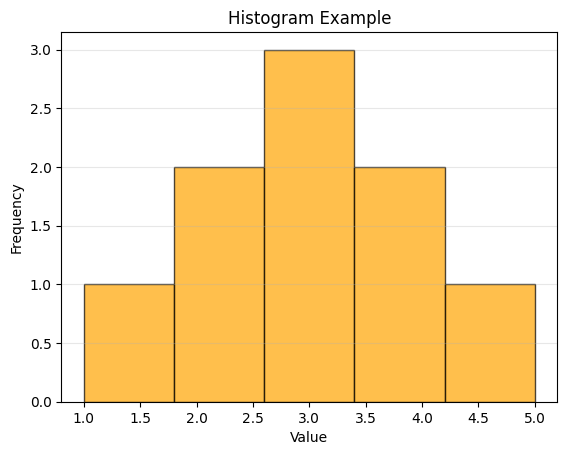

In [112]:
fig, ax = plt.subplots()

data = [1, 2, 2, 3, 3, 3, 4, 4, 5]

ax.hist(data, bins=5, color='orange',edgecolor='black',alpha=0.7)

ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title('Histogram Example')
ax.grid(True, alpha=0.3, axis='y')

plt.show()

#### Pie Chart
Show proportions of a whole

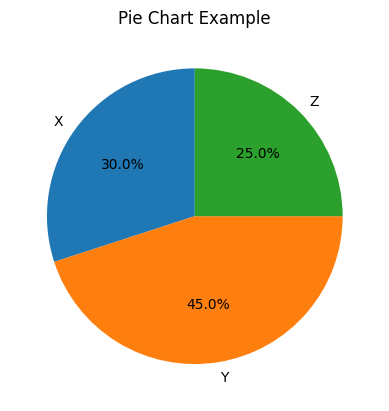

In [113]:
fig, ax = plt.subplots()
sizes = [30, 45, 25]
labels = ['X', 'Y', 'Z']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Pie Chart Example')
plt.show()


#### Box Plot
Show distribution with quartiles and outliers

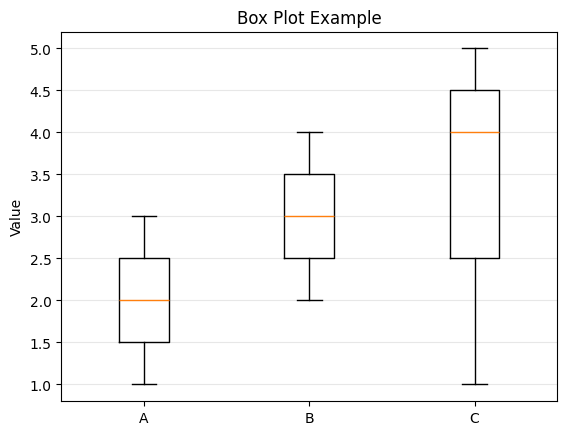

In [114]:
fig, ax = plt.subplots()
data = [[1, 2, 3], [2, 3, 4], [1, 4, 5]]
ax.boxplot(data, tick_labels=['A', 'B', 'C'])
ax.set_ylabel('Value')
ax.set_title('Box Plot Example')
ax.grid(True, alpha=0.3, axis='y')
plt.show()


#### Horizontal Bar Chart & Error Bars
Rankings/comparisons & show uncertainty in data points

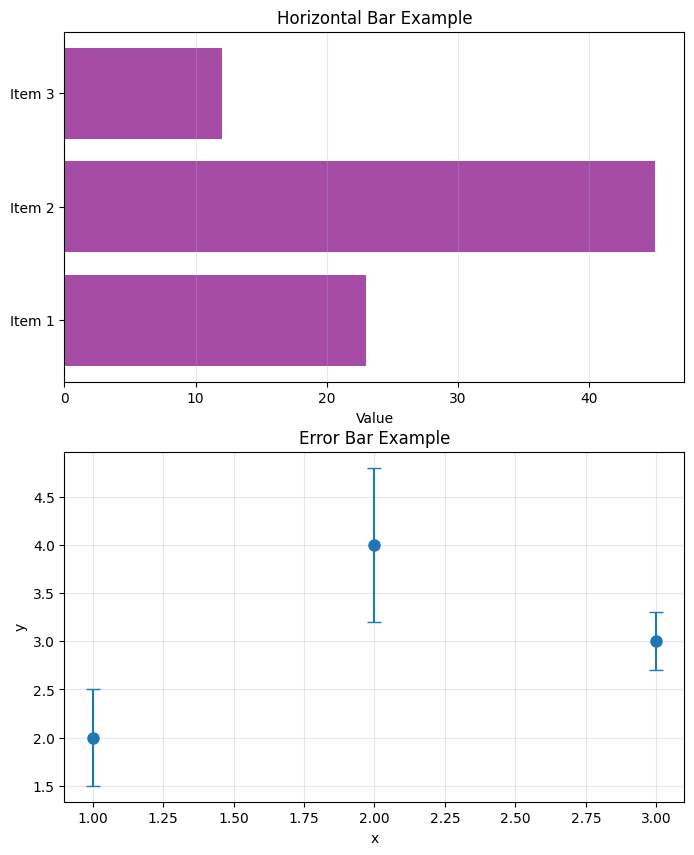

In [115]:
# multiple plots on the same figure
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))

items = ['Item 1', 'Item 2', 'Item 3']
values = [23, 45, 12]
ax1.barh(items, values, color='purple', alpha=0.7)
ax1.set_xlabel('Value')
ax1.set_title('Horizontal Bar Example')
ax1.grid(True, alpha=0.3, axis='x')

x = [1, 2, 3]
y = [2, 4, 3]
errors = [0.5, 0.8, 0.3]
ax2.errorbar(x, y, yerr=errors, fmt='o', capsize=5, markersize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Error Bar Example')
ax2.grid(True, alpha=0.3)
plt.show()

### 2.3 Drawing Vectors

For Geometric Algebra, we need to visualize vectors. There are two main methods:

1. **Lines**: Simple but no direction indicator
2. **Arrows (quiver)**: Shows direction clearly

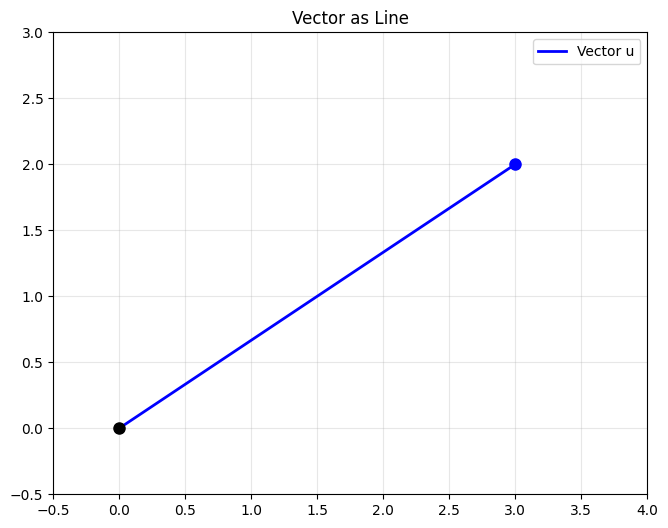

In [116]:
# Method 1: Lines
fig, ax = plt.subplots(figsize=(8, 6))

# Vector from (0,0) to (3,2)
ax.plot([0, 3], [0, 2], 'b-', linewidth=2, label='Vector u')
ax.plot(0, 0, 'ko', markersize=8)  # Origin
ax.plot(3, 2, 'bo', markersize=8)  # Endpoint

ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 3)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Vector as Line')

plt.show()

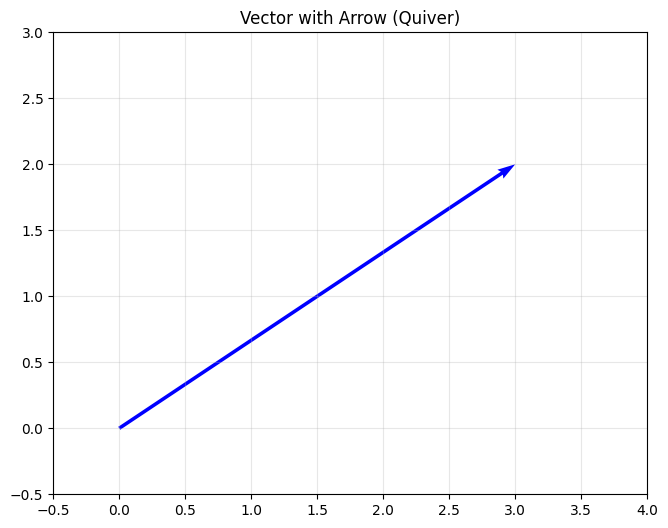

In [117]:
# Method 2: Arrows (quiver) - Better for vectors!
fig, ax = plt.subplots(figsize=(8, 6))

# Vector from (0,0) to (3,2)
ax.quiver(0, 0, 3, 2,
          angles='xy',      # Use data coordinates
          scale_units='xy', # Scale in data units
          scale=1,          # No scaling
          color='blue',
          width=0.006)

ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 3)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Vector with Arrow (Quiver)')

plt.show()

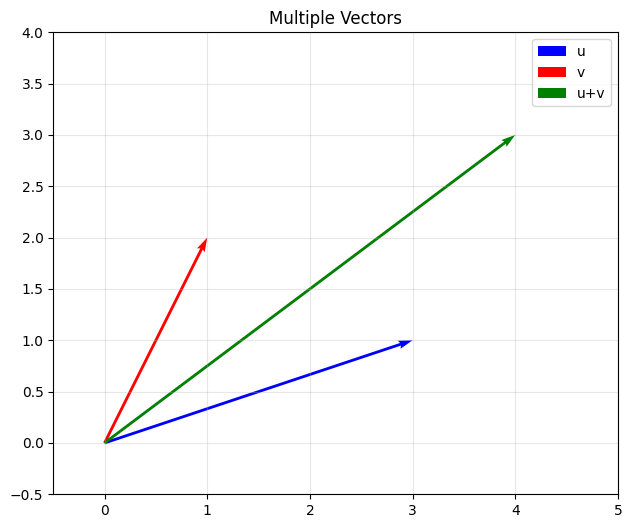

In [118]:
# Multiple vectors
fig, ax = plt.subplots(figsize=(8, 6))

# Vector u
ax.quiver(0, 0, 3, 1,
          angles='xy', scale_units='xy', scale=1,
          color='blue', width=0.005, label='u')

# Vector v
ax.quiver(0, 0, 1, 2,
          angles='xy', scale_units='xy', scale=1,
          color='red', width=0.005, label='v')

# Vector u+v
ax.quiver(0, 0, 4, 3,
          angles='xy', scale_units='xy', scale=1,
          color='green', width=0.005, label='u+v')

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 4)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Multiple Vectors')

plt.show()

### 2.4 Drawing Shapes (Polygons)

To visualize bivectors (areas), we need filled shapes:

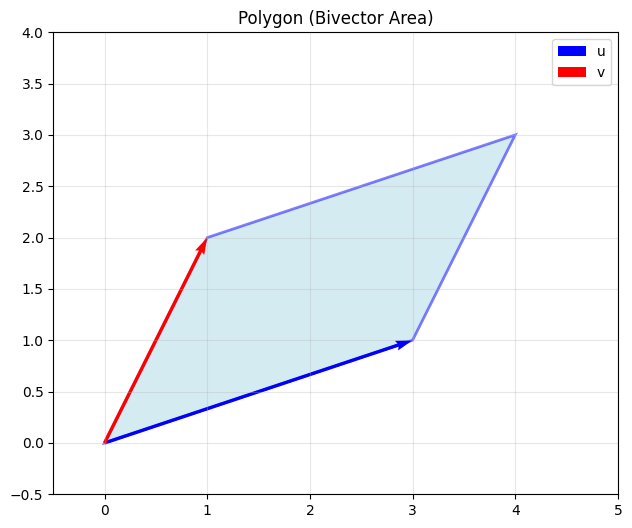

In [119]:
# Polygon example
fig, ax = plt.subplots(figsize=(8, 6))

# Define corners of a parallelogram
u = [3, 1]
v = [1, 2]
points = [
    [0, 0],                    # Origin
    u,                         # End of u
    [u[0]+v[0], u[1]+v[1]],    # u+v
    v                          # End of v
]

# Create and add polygon
shape = Polygon(points,
                facecolor='lightblue',
                edgecolor='blue',
                alpha=0.5,
                linewidth=2)
ax.add_patch(shape)

# Draw the vectors
ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1,
          color='blue', width=0.006, label='u')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='red', width=0.006, label='v')

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 4)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Polygon (Bivector Area)')

plt.show()

### 2.5 Adding plot() Method to Vector Class

Now let's enhance our Vector class so vectors can draw themselves!

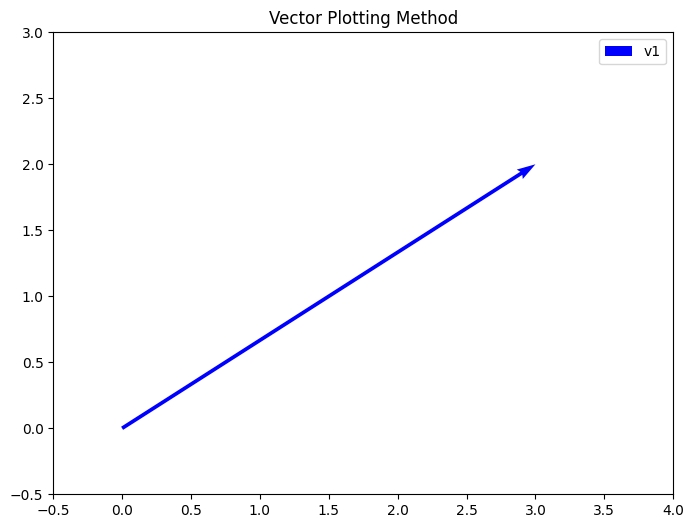

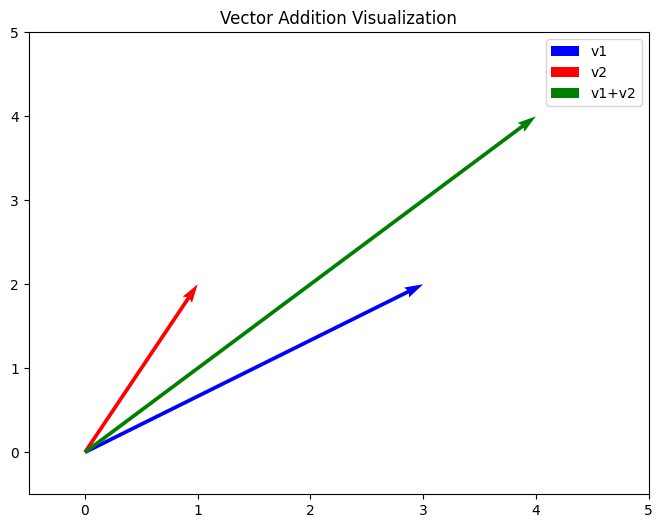

In [120]:
# Enhanced Vector class with plot() method
class Vector:
    """A 2D vector for Geometric Algebra with visualization."""
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self._array = np.array([x, y])
    
    def __str__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __repr__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __add__(self, other):
        new_array = self._array + other._array
        return Vector(new_array[0], new_array[1])
    
    def __sub__(self, other):
        new_array = self._array - other._array
        return Vector(new_array[0], new_array[1])
    
    def __mul__(self, scalar):
        return Vector(self.x * scalar, self.y * scalar)
    
    def magnitude(self):
        return np.linalg.norm(self._array)
    
    def plot(self, ax=None, **kwargs):
        """Plot this vector as an arrow from the origin."""
        if ax is None:
            fig, ax = plt.subplots()
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
        
        # Default styling
        defaults = {
            'angles': 'xy',
            'scale_units': 'xy',
            'scale': 1,
            'width': 0.006,
            'color': 'blue'
        }
        defaults.update(kwargs)
        
        # Draw the vector
        ax.quiver(0, 0, self.x, self.y, **defaults)
        return ax

# Test the plot method
v1 = Vector(3, 2)
v2 = Vector(1, 2)

# Single vector
fig, ax = plt.subplots(figsize=(8, 6))
v1.plot(ax=ax, color='blue', label='v1')
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 3)
ax.legend()
ax.set_title('Vector Plotting Method')
plt.show()

# Multiple vectors
fig, ax = plt.subplots(figsize=(8, 6))
v1.plot(ax=ax, color='blue', label='v1')
v2.plot(ax=ax, color='red', label='v2')
(v1 + v2).plot(ax=ax, color='green', label='v1+v2')
ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 5)
ax.legend()
ax.set_title('Vector Addition Visualization')
plt.show()

## Part 3: The Geometric Product

### 3.1 The Formula

The fundamental identity of Geometric Algebra:

$$uv = u \cdot v + u \wedge v$$

Where:
- **Dot product** ($u \cdot v$): Scalar, measures parallelism
  - Formula: $u_x v_x + u_y v_y$
  - Symmetric: $u \cdot v = v \cdot u$
  - Zero when orthogonal

- **Wedge product** ($u \wedge v$): Bivector, measures area
  - Formula: $u_x v_y - u_y v_x$
  - Antisymmetric: $u \wedge v = -(v \wedge u)$
  - Zero when parallel

### 3.2 Implementing the Dot Product

In [121]:
# Add dot product to Vector class
class Vector:
    """A 2D vector for Geometric Algebra."""
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self._array = np.array([x, y])
    
    def __str__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __repr__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __add__(self, other):
        new_array = self._array + other._array
        return Vector(new_array[0], new_array[1])
    
    def __sub__(self, other):
        new_array = self._array - other._array
        return Vector(new_array[0], new_array[1])
    
    def __mul__(self, scalar):
        return Vector(self.x * scalar, self.y * scalar)
    
    def magnitude(self):
        return np.linalg.norm(self._array)
    
    def dot(self, other):
        """Dot product: u·v (scalar result)."""
        return self.x * other.x + self.y * other.y
    
    def plot(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots()
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
        
        defaults = {
            'angles': 'xy',
            'scale_units': 'xy',
            'scale': 1,
            'width': 0.006,
            'color': 'blue'
        }
        defaults.update(kwargs)
        ax.quiver(0, 0, self.x, self.y, **defaults)
        return ax

# Test dot product
u = Vector(2, 1)
v = Vector(1, 2)

print(f"u = {u}")
print(f"v = {v}")
print(f"u·v = {u.dot(v)}")

# Test orthogonal vectors
a = Vector(3, 0)
b = Vector(0, 4)
print(f"\na = {a}")
print(f"b = {b}")
print(f"a·b = {a.dot(b)} (orthogonal!)")

u = Vector(2, 1)
v = Vector(1, 2)
u·v = 4

a = Vector(3, 0)
b = Vector(0, 4)
a·b = 0 (orthogonal!)


### 3.3 Implementing the Wedge Product

In [122]:
# Add wedge product to Vector class
class Vector:
    """Complete Vector class with geometric algebra operations."""
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self._array = np.array([x, y])
    
    def __str__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __repr__(self):
        return f"Vector({self.x}, {self.y})"
    
    def __add__(self, other):
        new_array = self._array + other._array
        return Vector(new_array[0], new_array[1])
    
    def __sub__(self, other):
        new_array = self._array - other._array
        return Vector(new_array[0], new_array[1])
    
    def __mul__(self, other):
        """Overload * for both scalar multiplication and geometric product."""
        if isinstance(other, Vector):
            return self.geometric_product(other)
        else:
            # Scalar multiplication
            return Vector(self.x * other, self.y * other)
    
    def magnitude(self):
        return np.linalg.norm(self._array)
    
    def dot(self, other):
        """Dot product: u·v (scalar)."""
        return self.x * other.x + self.y * other.y
    
    def wedge(self, other):
        """Wedge product: u∧v (signed area)."""
        return self.x * other.y - self.y * other.x
    
    def geometric_product(self, other):
        """Geometric product: uv = u·v + u∧v.
        
        Returns:
            tuple: (scalar, bivector)
        """
        scalar = self.dot(other)
        bivector = self.wedge(other)
        return (scalar, bivector)
    
    def plot(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots()
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
        
        defaults = {
            'angles': 'xy',
            'scale_units': 'xy',
            'scale': 1,
            'width': 0.006,
            'color': 'blue'
        }
        defaults.update(kwargs)
        ax.quiver(0, 0, self.x, self.y, **defaults)
        return ax

# Test wedge product
u = Vector(2, 1)
v = Vector(1, 2)

print(f"u = {u}")
print(f"v = {v}")
print(f"u∧v = {u.wedge(v)}")
print(f"v∧u = {v.wedge(u)} (antisymmetric!)")

# Test parallel vectors
p = Vector(2, 1)
q = Vector(4, 2)  # q = 2*p
print(f"\np = {p}")
print(f"q = {q} (parallel to p)")
print(f"p∧q = {p.wedge(q)} (parallel vectors have zero wedge product!)")

u = Vector(2, 1)
v = Vector(1, 2)
u∧v = 3
v∧u = -3 (antisymmetric!)

p = Vector(2, 1)
q = Vector(4, 2) (parallel to p)
p∧q = 0 (parallel vectors have zero wedge product!)


### 3.4 The Complete Geometric Product

Now we can use the `*` operator for the geometric product!

In [123]:
# Test geometric product
u = Vector(2, 1)
v = Vector(1, 2)

# Using the method
scalar, bivector = u.geometric_product(v)
print(f"u = {u}")
print(f"v = {v}")
print(f"\nUsing method:")
print(f"u·v = {scalar}")
print(f"u∧v = {bivector}")
print(f"uv = {scalar} + {bivector}")

# Using the * operator
result = u * v
print(f"\nUsing * operator:")
print(f"u * v = {result}")

# Verify the formula
print(f"\nVerification:")
print(f"u·v + u∧v = {u.dot(v)} + {u.wedge(v)} = {u.dot(v) + u.wedge(v)}")

u = Vector(2, 1)
v = Vector(1, 2)

Using method:
u·v = 4
u∧v = 3
uv = 4 + 3

Using * operator:
u * v = (4, 3)

Verification:
u·v + u∧v = 4 + 3 = 7


### 3.5 Visualizing the Geometric Product

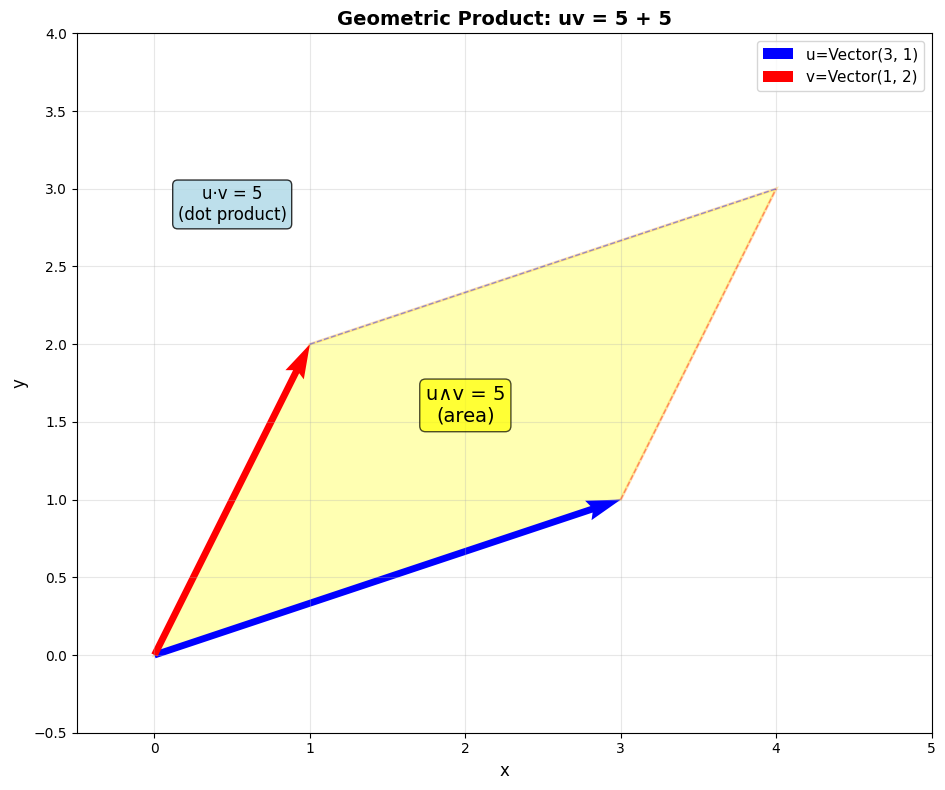

In [124]:
# Complete visualization of geometric product
u = Vector(3, 1)
v = Vector(1, 2)

# Calculate geometric product
scalar, bivector = u * v

# Create visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Draw bivector area (parallelogram)
points = [[0, 0], [u.x, u.y], [u.x+v.x, u.y+v.y], [v.x, v.y]]
shape = Polygon(points, facecolor='yellow', alpha=0.3, 
                edgecolor='orange', linewidth=2)
ax.add_patch(shape)

# Draw vectors
u.plot(ax=ax, color='blue', width=0.008, label=f'u={u}')
v.plot(ax=ax, color='red', width=0.008, label=f'v={v}')

# Draw completion lines (dashed)
ax.plot([u.x, u.x+v.x], [u.y, u.y+v.y], 'r--', alpha=0.4, linewidth=1)
ax.plot([v.x, u.x+v.x], [v.y, u.y+v.y], 'b--', alpha=0.4, linewidth=1)

# Add annotations
ax.text(2, 1.5, f'u∧v = {bivector}\n(area)', fontsize=14, ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax.text(0.5, 2.8, f'u·v = {scalar}\n(dot product)', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Format
ax.legend(fontsize=11, loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(f'Geometric Product: uv = {scalar} + {bivector}', 
             fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

## Practice Problems

Now try solving the lecture exercises using our Vector class!

### Exercise 1: Given vectors a = (2, 1) and b = (1, 2)

(a) Calculate their inner product a·b  
(b) Calculate their outer product a∧b  
(c) Calculate their geometric product ab  
(d) Verify that ab = a·b + a∧b

Exercise 1:
a = Vector(2, 1)
b = Vector(1, 2)

(a) a·b = 4
(b) a∧b = 3
(c) ab = (4, 3)
(d) Verification:
    a·b = 4
    a∧b = 3
    a·b + a∧b = 7


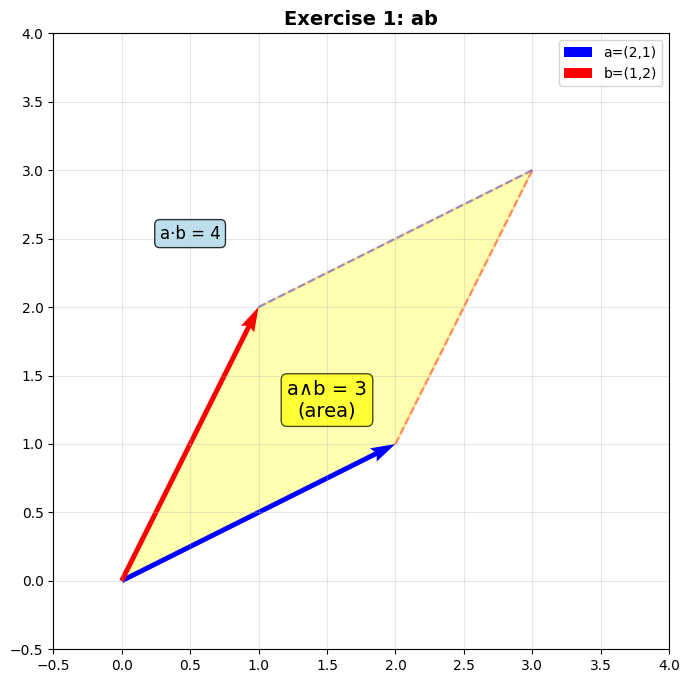

In [125]:
# Exercise 1 - Complete solution
a = Vector(2, 1)
b = Vector(1, 2)

print("Exercise 1:")
print(f"a = {a}")
print(f"b = {b}")
print()

# (a) Inner product (dot product)
dot_product = a.dot(b)
print(f"(a) a·b = {dot_product}")

# (b) Outer product (wedge product)
wedge_product = a.wedge(b)
print(f"(b) a∧b = {wedge_product}")

# (c) Geometric product
scalar, bivector = a * b
print(f"(c) ab = ({scalar}, {bivector})")

# (d) Verification
print(f"(d) Verification:")
print(f"    a·b = {dot_product}")
print(f"    a∧b = {wedge_product}")
print(f"    a·b + a∧b = {dot_product + wedge_product}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

# Bivector area
points = [[0, 0], [a.x, a.y], [a.x+b.x, a.y+b.y], [b.x, b.y]]
shape = Polygon(points, facecolor='yellow', alpha=0.3, edgecolor='orange', linewidth=2)
ax.add_patch(shape)

# Vectors
a.plot(ax=ax, color='blue', width=0.008, label='a=(2,1)')
b.plot(ax=ax, color='red', width=0.008, label='b=(1,2)')

# Dashed lines
ax.plot([a.x, a.x+b.x], [a.y, a.y+b.y], 'r--', alpha=0.4)
ax.plot([b.x, a.x+b.x], [b.y, a.y+b.y], 'b--', alpha=0.4)

# Annotations
ax.text(1.5, 1.2, f'a∧b = {bivector}\n(area)', fontsize=14, ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax.text(0.5, 2.5, f'a·b = {dot_product}', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 4)
ax.set_title(f'Exercise 1: ab', fontsize=14, weight='bold')
plt.show()

## Summary

In this tutorial, we:

1. **Built a Vector class from scratch** using OOP principles
   - Properties (data): `x`, `y`, `_array`
   - Methods (behavior): `magnitude()`, `dot()`, `wedge()`, `geometric_product()`, `plot()`
   - Magic methods: `__add__`, `__sub__`, `__mul__`, `__str__`, `__repr__`

2. **Learned Matplotlib visualization**
   - Hierarchy: Figure → Axes → Axis → Artists
   - Drawing vectors with `quiver()`
   - Drawing areas with `Polygon()`
   - Custom `plot()` method for vectors

3. **Implemented the Geometric Product**
   - Dot product: measures parallelism (scalar)
   - Wedge product: measures area (bivector)
   - Geometric product: combines both ($uv = u \cdot v + u \wedge v$)
   - Visualized the results

## Proposed Exercises

Here are 8 exercises. Try to solve them before looking at the provided solutions!

### Part 1: Object-Oriented Programming (Classes)

**Exercise 1: The Rectangle Class** \
Create a class called `Rectangle` with attributes `width` and `height` and methods `area` and `perimeter`.

**Exercise 2: The Circle Class** \
Create a class called `Circle` with the attribute `radius`. Include methods to calculate the `area` ($\pi r^2$) and `circumference` ($2 \pi r$). Use `np.pi` for the value of $\pi$.

**Exercise 3: Bank Account System** \
Create a `BankAccount` class that initializes with an `owner_name` and a `balance` (default 0). Add methods for `deposit(amount)` and `withdraw(amount)`. Ensure that a withdrawal cannot happen if the amount exceeds the balance.

### Part 2: Graphing with Matplotlib

**Exercise 4: Sine and Cosine Waves** \
Plot the functions $y = \sin(x)$ and $y = \cos(x)$ for $x$ in the range $[0, 2\pi]$ on the **same plot**. Label the axes, add a title, and include a legend. Use `np.linspace` to generate the x values.

**Exercise 5: Student Grades Breakdown (Subplots)** \
Plot bar charts of the student grades. Create a figure with 3 subplots:
- Top row (spanning the whole width): Total students in each grade.
- Bottom row left: Only boys.
- Bottom row right: Only girls.

*Hint: Use `fig.add_subplot(2, 2, (1, 2))` to make a subplot span across multiple columns!*

Data: 
- `grades = ['A', 'B', 'C', 'D', 'F']`
- `boys = [5, 10, 5, 2, 1]`
- `girls = [7, 8, 5, 2, 0]`

**Exercise 6: Histogram with Error Bars and Gaussian Fit** \
Plot a histogram of the given weights of students using 6 bins. Then:
1. Extract the bin counts ($N$) and add **error bars** to the histogram (should be placed on the **center** of each bin) using the formula: $\text{Error} = \sqrt{N}$.
   *(Hint: The `ax.hist()` function doesn't just draw a picture! It actually computes and returns information!)*
2. Calculate the mean ($\mu$) and standard deviation ($\sigma$) of the weights.
3. Plot a **Gaussian curve** on top of the histogram by translating this mathematical function into Python code:
   
   $$f(x) = A \cdot \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
   
   *(Where $A$ is the scaling area: `Total number of students * bin_width`)*

Data: `weights = [55, 62, 65, 68, 70, 72, 72, 74, 75, 78, 80, 82, 85, 90, 95]`

### Part 3: Class Challenges (OOP + Matplotlib + Math)

*Note: These exercises rely on the `Vector` class we built during the tutorial. Ensure you have run those cells first!*

**Exercise 7: Vector Addition and Bivectors (OOP Style)** \
Extend the `Vector` class concepts by adding a `plot_sum(self, other, show_bivector=False)` **method** directly into the class. It should show:
- The original vector `self` (blue)
- The `other` vector (red)  
- The sum `self + other` (green)
- All three on the same plot!
- *Bonus:* If `show_bivector` is True, draw the parallelogram area representing the bivector!

*(Hint: To avoid rewriting the entire class in this cell, you can define the function normally and then attach it to the existing class using `Vector.plot_sum = plot_sum`!)*

**Exercise 8: The Geometric Product Visualizer** \
Add a `plot_geometric_product(self, other)` **method** that visualizes BOTH the dot product and wedge product on the same plot! 
- The **wedge product** should be shown as the bivector parallelogram.
- The **dot product** is a scalar, so project `self` onto `other` and display the resulting scalar value as text on the plot.

*Design Note: In Python, we could have written this as a standalone function `plot_product(u, v)`. However, making it a method `u.plot_geometric_product(v)` is a deliberate OOP choice. It strictly bundles the visualization logic with the data it represents!*

**Exercise 9: Advanced Vector Mathematics** \
Extend the `Vector` class with two new methods:
1. `normalize()`: Returns a new `Vector` that points in the exact same direction, but has a magnitude (length) of exactly 1.
2. `angle_between(other)`: Calculates the angle $\theta$ between this vector and another vector. *(Hint: Use the dot product definition: $u \cdot v = |u||v|\cos(\theta)$. )*

In [126]:
# Solution 1
class Rectangle:
    """A rectangle with width and height."""
    
    def __init__(self, width, height):
        self.width = width
        self.height = height
    
    def area(self):
        """Calculate and return the area."""
        return self.width * self.height
    
    def perimeter(self):
        """Calculate and return the perimeter."""
        return 2 * (self.width + self.height)

# Test
rect = Rectangle(5, 3)
print(f"Width: {rect.width}, Height: {rect.height}")
print(f"Area: {rect.area()}")           # 15
print(f"Perimeter: {rect.perimeter()}") # 16

Width: 5, Height: 3
Area: 15
Perimeter: 16


In [127]:
# Solution 2
import numpy as np

class Circle:
    def __init__(self, radius):
        self.radius = radius
        
    def area(self):
        return np.pi * (self.radius ** 2)
        
    def circumference(self):
        return 2 * np.pi * self.radius

# Test
circle = Circle(4)
print(f"Radius: {circle.radius}")
print(f"Area: {circle.area():.2f}")
print(f"Circumference: {circle.circumference():.2f}")

Radius: 4
Area: 50.27
Circumference: 25.13


In [128]:
# Solution 3
class BankAccount:
    def __init__(self, owner_name, balance=0.0):
        self.owner_name = owner_name
        self.balance = balance
        
    def deposit(self, amount):
        if amount > 0:
            self.balance += amount
            print(f"Deposited ${amount}. New balance: ${self.balance}")
            
    def withdraw(self, amount):
        if amount > self.balance:
            print("Error: Insufficient funds!")
        elif amount > 0:
            self.balance -= amount
            print(f"Withdrew ${amount}. New balance: ${self.balance}")

# Test
account = BankAccount("Alice", 100)
account.deposit(50)
account.withdraw(200) # Should fail
account.withdraw(30)

Deposited $50. New balance: $150
Error: Insufficient funds!
Withdrew $30. New balance: $120


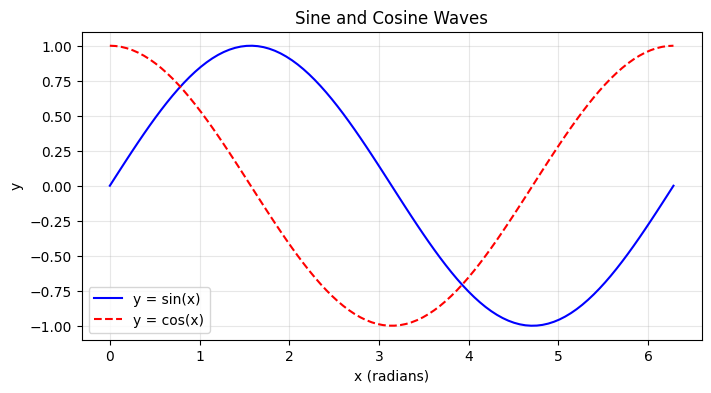

In [129]:
# Solution 4
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y_sin, label='y = sin(x)', color='blue')
ax.plot(x, y_cos, label='y = cos(x)', color='red', linestyle='--')

ax.set_xlabel('x (radians)')
ax.set_ylabel('y')
ax.set_title('Sine and Cosine Waves')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

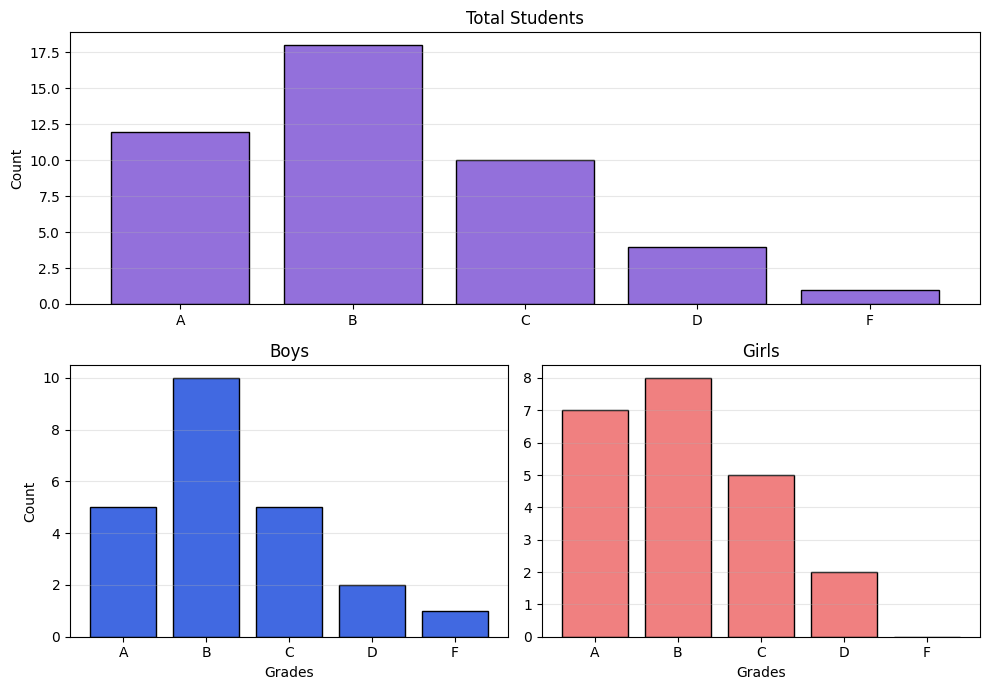

In [130]:
# Solution 5
grades = ['A', 'B', 'C', 'D', 'F']
boys = [5, 10, 5, 2, 1]
girls = [7, 8, 5, 2, 0]

# Calculate total by adding boys and girls lists together element-by-element
total = [b + g for b, g in zip(boys, girls)]

# Create the figure
fig = plt.figure(figsize=(10, 7))

# 1. Top row: All students (spans columns 1 and 2 of a 2x2 grid)
ax1 = fig.add_subplot(2, 2, (1, 2))
ax1.bar(grades, total, color='mediumpurple', edgecolor='black')
ax1.set_title('Total Students')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# 2. Bottom row left: Boys
ax2 = fig.add_subplot(2, 2, 3)
ax2.bar(grades, boys, color='royalblue', edgecolor='black')
ax2.set_title('Boys')
ax2.set_xlabel('Grades')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

# 3. Bottom row right: Girls
ax3 = fig.add_subplot(2, 2, 4)
ax3.bar(grades, girls, color='lightcoral', edgecolor='black')
ax3.set_title('Girls')
ax3.set_xlabel('Grades')
ax3.grid(axis='y', alpha=0.3)

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

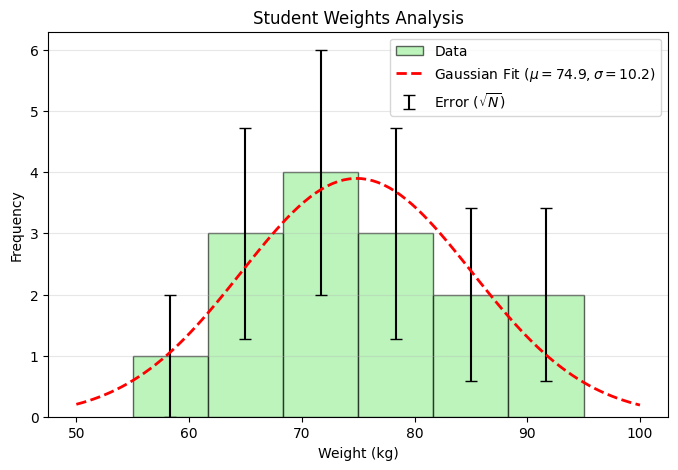

In [145]:
# Solution 6
import numpy as np

weights = [55, 62, 65, 68, 70, 72, 72, 74, 75, 78, 80, 82, 85, 90, 95]

fig, ax = plt.subplots(figsize=(8, 5))

# 1. Plot Histogram and capture the returned data
# ax.hist returns the counts per bin, the bin edges, and the drawn patches
counts, bin_edges, _ = ax.hist(weights, bins=6, color='lightgreen', edgecolor='black', alpha=0.6, label='Data')

# 2. Add Error Bars (Statistical error = sqrt(N))
# Find the middle of each bin to place the error bar
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
errors = np.sqrt(counts)

# Note: We use r"..." (raw string) before strings containing LaTeX notation, as in Python, 
# the backslash '\' is special (e.g. '\n' = newline, '\t' = tab).This way it doesn't throw
# a SyntaxWarning for unknown escape sequences like '\s' in this case.
ax.errorbar(bin_centers, counts, yerr=errors, fmt='none', ecolor='black', capsize=4, label=r'Error ($\sqrt{N}$)')

# 3. Calculate and Plot Gaussian Fit
mu = np.mean(weights)
std = np.std(weights)

# Create an array of x values for the smooth curve
x_curve = np.linspace(min(weights) - 5, max(weights) + 5, 100)

# The standard Gaussian Probability Density Function (PDF)
pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_curve - mu) / std)**2)

# Scale the PDF so it matches the histogram counts
# Scaling factor = Total number of samples * bin width
bin_width = bin_edges[1] - bin_edges[0]
scaled_pdf = pdf * len(weights) * bin_width

# Plot the curve
label = rf'Gaussian Fit ($\mu={mu:.1f}, \sigma={std:.1f}$)'
ax.plot(x_curve, scaled_pdf, 'r--', linewidth=2, label=label)

ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Frequency')
ax.set_title('Student Weights Analysis')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.show()

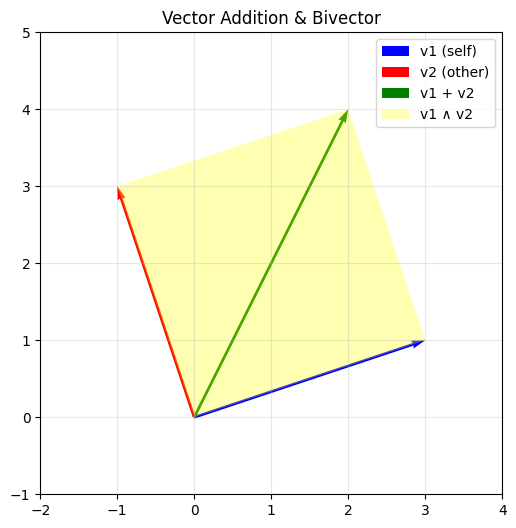

In [132]:
# Solution 7
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt

def plot_sum(self, other, show_bivector=False):
    """Method to plot this vector, another vector, and their sum."""
    fig, ax = plt.subplots(figsize=(6,6))
    
    # Use the plot method already inside our Vector class
    self.plot(ax=ax, color='blue', label='v1 (self)')
    other.plot(ax=ax, color='red', label='v2 (other)')
    
    # Calculate sum using the overloaded __add__ operator
    v_sum = self + other
    v_sum.plot(ax=ax, color='green', label='v1 + v2')
    
    if show_bivector:
        # Draw the parallelogram formed by self and other
        points = [[0,0], [self.x, self.y], [v_sum.x, v_sum.y], [other.x, other.y]]
        shape = Polygon(points, alpha=0.3, facecolor='yellow', edgecolor='none', label='v1 ∧ v2')
        ax.add_patch(shape)
    
    ax.legend()
    ax.set_aspect('equal')
    
    # Dynamic axis limits
    all_x = [0, self.x, other.x, v_sum.x]
    all_y = [0, self.y, other.y, v_sum.y]
    ax.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax.set_ylim(min(all_y) - 1, max(all_y) + 1)
    
    ax.grid(True, alpha=0.3)
    ax.set_title("Vector Addition & Bivector")
    plt.show()

# Magically attach this new function to our existing Vector class as a method
Vector.plot_sum = plot_sum

test_v1 = Vector(3, 1)
test_v2 = Vector(-1, 3)
test_v1.plot_sum(test_v2, show_bivector=True)

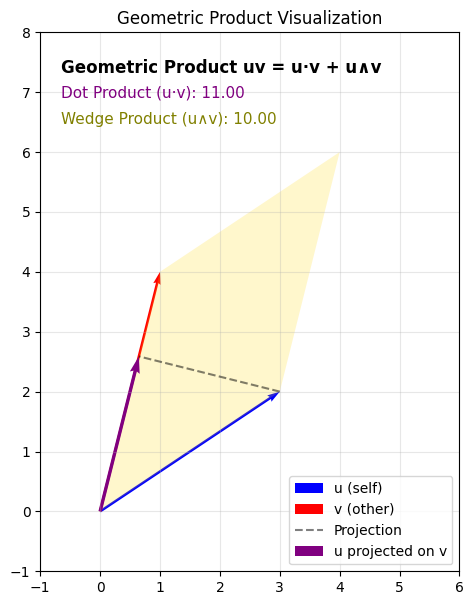

In [133]:
# Solution 8
def plot_geometric_product(self, other):
    """Visualizes the geometric product (dot + wedge) of self and other."""
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # 1. Plot original vectors
    self.plot(ax=ax, color='blue', label='u (self)')
    other.plot(ax=ax, color='red', label='v (other)')
    
    # 2. Wedge Product (Bivector Area)
    v_sum = self + other
    points = [[0,0], [self.x, self.y], [v_sum.x, v_sum.y], [other.x, other.y]]
    shape = Polygon(points, alpha=0.2, facecolor='gold', edgecolor='none')
    ax.add_patch(shape)
    
    # Calculate Math using our class methods
    dot_val = self.dot(other)
    wedge_val = self.wedge(other)
    
    # 3. Dot Product (Projection of self onto other)
    # Projection formula: proj_v(u) = (u·v / |v|^2) * v
    other_mag_sq = other.x**2 + other.y**2
    scalar_proj = dot_val / other_mag_sq
    proj_x = scalar_proj * other.x
    proj_y = scalar_proj * other.y
    
    # Draw projection line and vector
    ax.plot([self.x, proj_x], [self.y, proj_y], 'k--', alpha=0.5, label='Projection')
    ax.quiver(0, 0, proj_x, proj_y, angles='xy', scale_units='xy', scale=1, 
              color='purple', width=0.008, label='u projected on v')
    
    # 4. Annotations
    ax.text(0.05, 0.95, f"Geometric Product uv = u·v + u∧v", 
            transform=ax.transAxes, fontsize=12, verticalalignment='top', fontweight='bold')
    ax.text(0.05, 0.88, f"Dot Product (u·v): {dot_val:.2f}", 
            transform=ax.transAxes, fontsize=11, color='purple')
    ax.text(0.05, 0.83, f"Wedge Product (u∧v): {wedge_val:.2f}", 
            transform=ax.transAxes, fontsize=11, color='olive')
    
    # Styling
    ax.legend(loc='lower right')
    ax.set_aspect('equal')
    
    # Dynamic limits
    all_x = [0, self.x, other.x, v_sum.x]
    all_y = [0, self.y, other.y, v_sum.y]
    ax.set_xlim(min(all_x) - 1, max(all_x) + 2)
    ax.set_ylim(min(all_y) - 1, max(all_y) + 2)
    
    ax.grid(True, alpha=0.3)
    ax.set_title("Geometric Product Visualization")
    
    plt.show()

# Attach to the class
Vector.plot_geometric_product = plot_geometric_product

vec_u = Vector(3, 2)
vec_v = Vector(1, 4)
vec_u.plot_geometric_product(vec_v)

In [134]:
# Solution 9
import numpy as np

def normalize(self):
    """Returns a unit vector (magnitude of 1) in the same direction."""
    mag = self.magnitude()
    if mag == 0:
        raise ValueError("Cannot normalize a zero vector.") # We ll see this in a further class
    # Return a new instance of our existing Vector class
    return Vector(self.x / mag, self.y / mag)
    
def angle_between(self, other, in_degrees=False):
    """Calculates the angle between this vector and another."""
    dot_product = self.dot(other)
    mags = self.magnitude() * other.magnitude()
    
    # Prevent math domain errors due to floating point precision
    cos_theta = np.clip(dot_product / mags, -1.0, 1.0) # ensures it is between -1 and 1
    
    angle_rad = np.arccos(cos_theta)
    
    if in_degrees:
        return np.degrees(angle_rad)
    return angle_rad

# Attach the new methods to the existing Vector class!
Vector.normalize = normalize
Vector.angle_between = angle_between

# Test new methods
v1 = Vector(3, 4)
v2 = Vector(4, 3)

v1_normalized = v1.normalize()
print(f"Original v1: {v1}, Magnitude: {v1.magnitude()}")
print(f"Normalized v1: {v1_normalized}, Magnitude: {v1_normalized.magnitude():.2f}")

angle_deg = v1.angle_between(v2, in_degrees=True)
print(f"Angle between v1 and v2: {angle_deg:.2f} degrees")

Original v1: Vector(3, 4), Magnitude: 5.0
Normalized v1: Vector(0.6, 0.8), Magnitude: 1.00
Angle between v1 and v2: 16.26 degrees
